In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

## **Data loading** ##

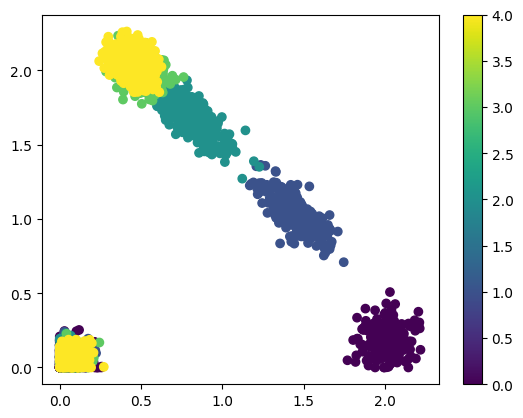

In [ ]:
data_name = 'simulation'
nu = 0.1
delta = 2
legend_loc = 'upper right'

# data_name = 'mouse'
# nu = 2
# delta = 15

# data_name = 'Dygen'
# nu = 0.1
# delta = 1.7
# legend_loc = 'upper left'

data = pd.read_csv('data/simulation_gene_data.csv')
# data = pd.read_csv('data/Weinreb_alltime.csv')
# data = pd.read_csv('data/dygen.csv')

t = np.array(data)[:,0]
X = np.array(data)[:,1:]
X1 = X[:,0]
X2 = X[:,1]
plt.scatter(X1,X2,c=t)
plt.colorbar()

## **Branching plot** ##

Plotting 12 trajectories...
Branching plot saved to branching_phase_portrait_simulation.png


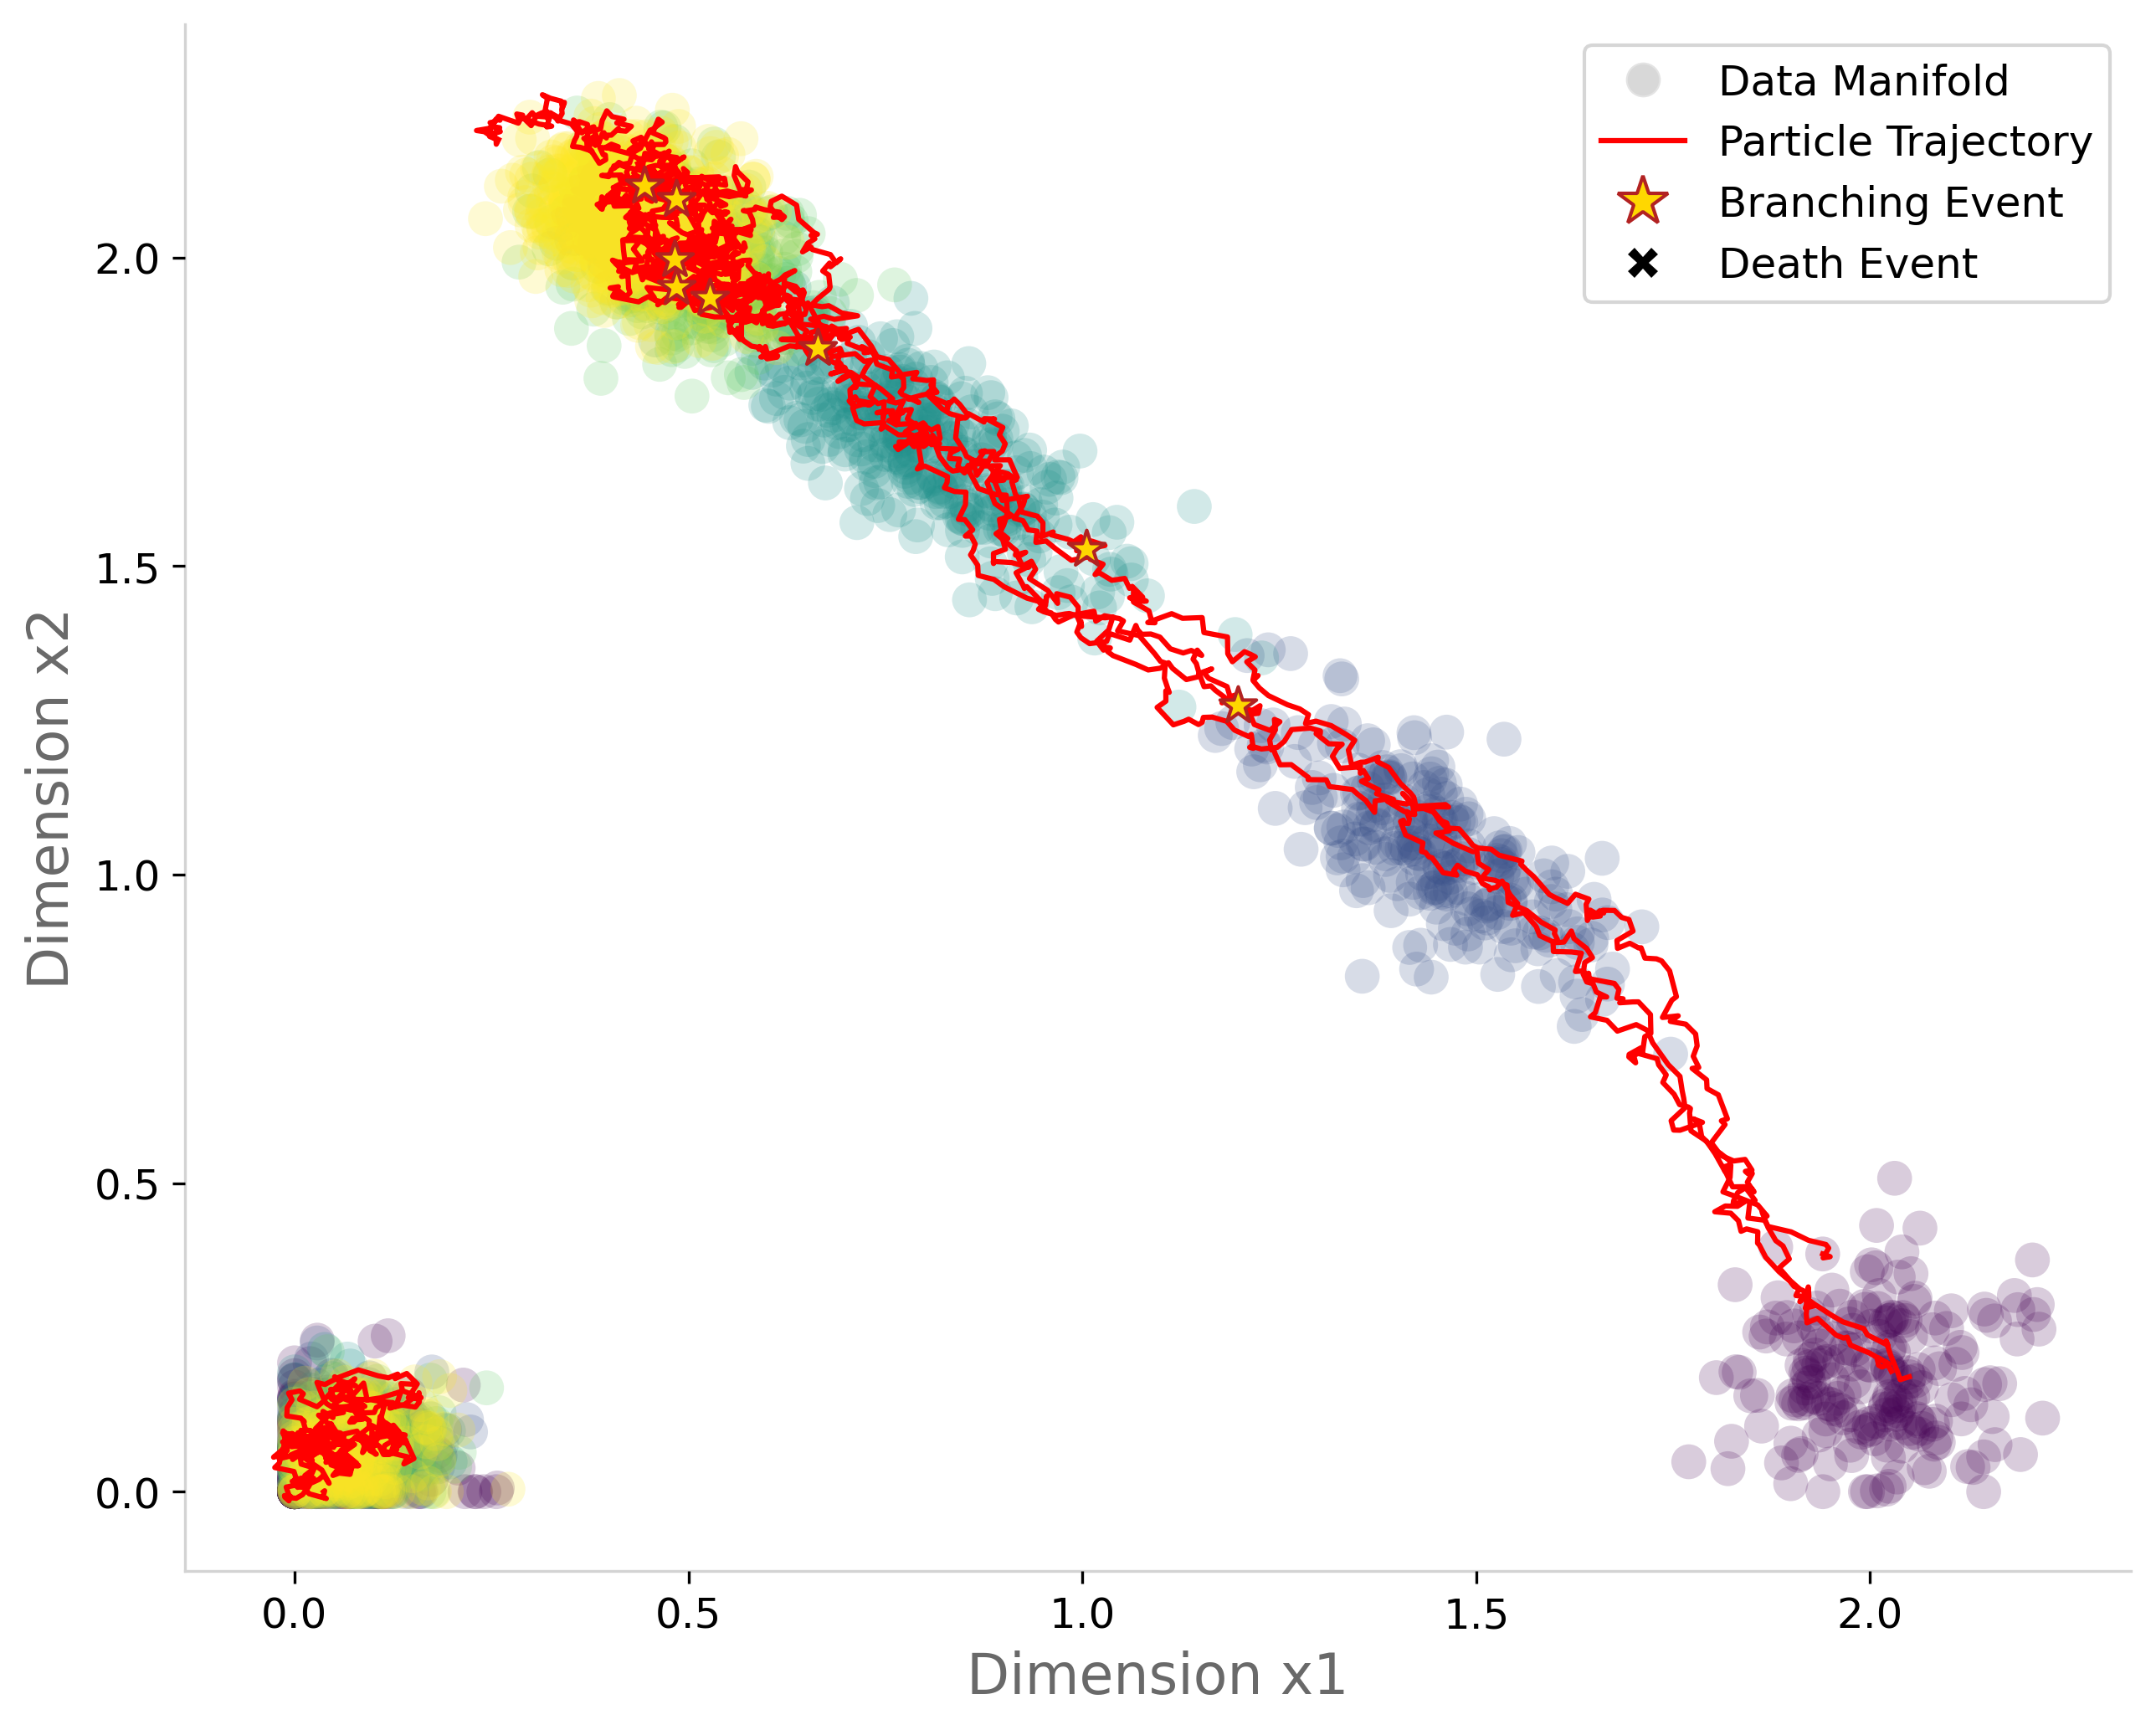

In [ ]:
from utils import SDE, plot_branching_phase_portrait, plot_branching_phase_portrait2
Xs = [] 
max_sample_time = int(np.max(data['samples']))
for k in range(max_sample_time + 1): 
    Xs.append(np.array(data[data['samples'] == k])[:, 1:]) 

model = torch.load(f'{data_name}_{delta}_{nu}.pth', weights_only=False, map_location=torch.device('cpu'))
model.eval()
simulator = SDE(model, nu, mode = 3, positive=False) 
        
# Simulation use X0[170,399]
# Dygen use X0[12,133,12,14,148,100,10,2,127]
# x_source = torch.tensor(Xs[0][np.array([0,1,2,3,4,5,6,7,8,9,10]),:], dtype=torch.float32, device = 'cpu') 


x_source = torch.tensor(Xs[0][np.array([0,10,170,300]),:], dtype=torch.float32, device = 'cpu') 
genealogy, ms, action = simulator.trajectory(
    x=x_source, 
    m=torch.zeros([x_source.size(0),1], device='cpu'), 
    delta=delta, 
    T=max_sample_time, 
    N=max_sample_time*100
) 
plot_branching_phase_portrait(
    df=data, 
    trajectories=genealogy, # 这里传入 mode=3 的字典
    simulation_t=max_sample_time,
    x='x1', y='x2',       # DataFrame 列名
    save=True, path='branching_phase_portrait_simulation.png',legend_loc = legend_loc
)

## **Branching plot with lineage** ##

Plotting 1 trajectories on existing ax...
Plotting 4 trajectories on existing ax...


KeyboardInterrupt: 

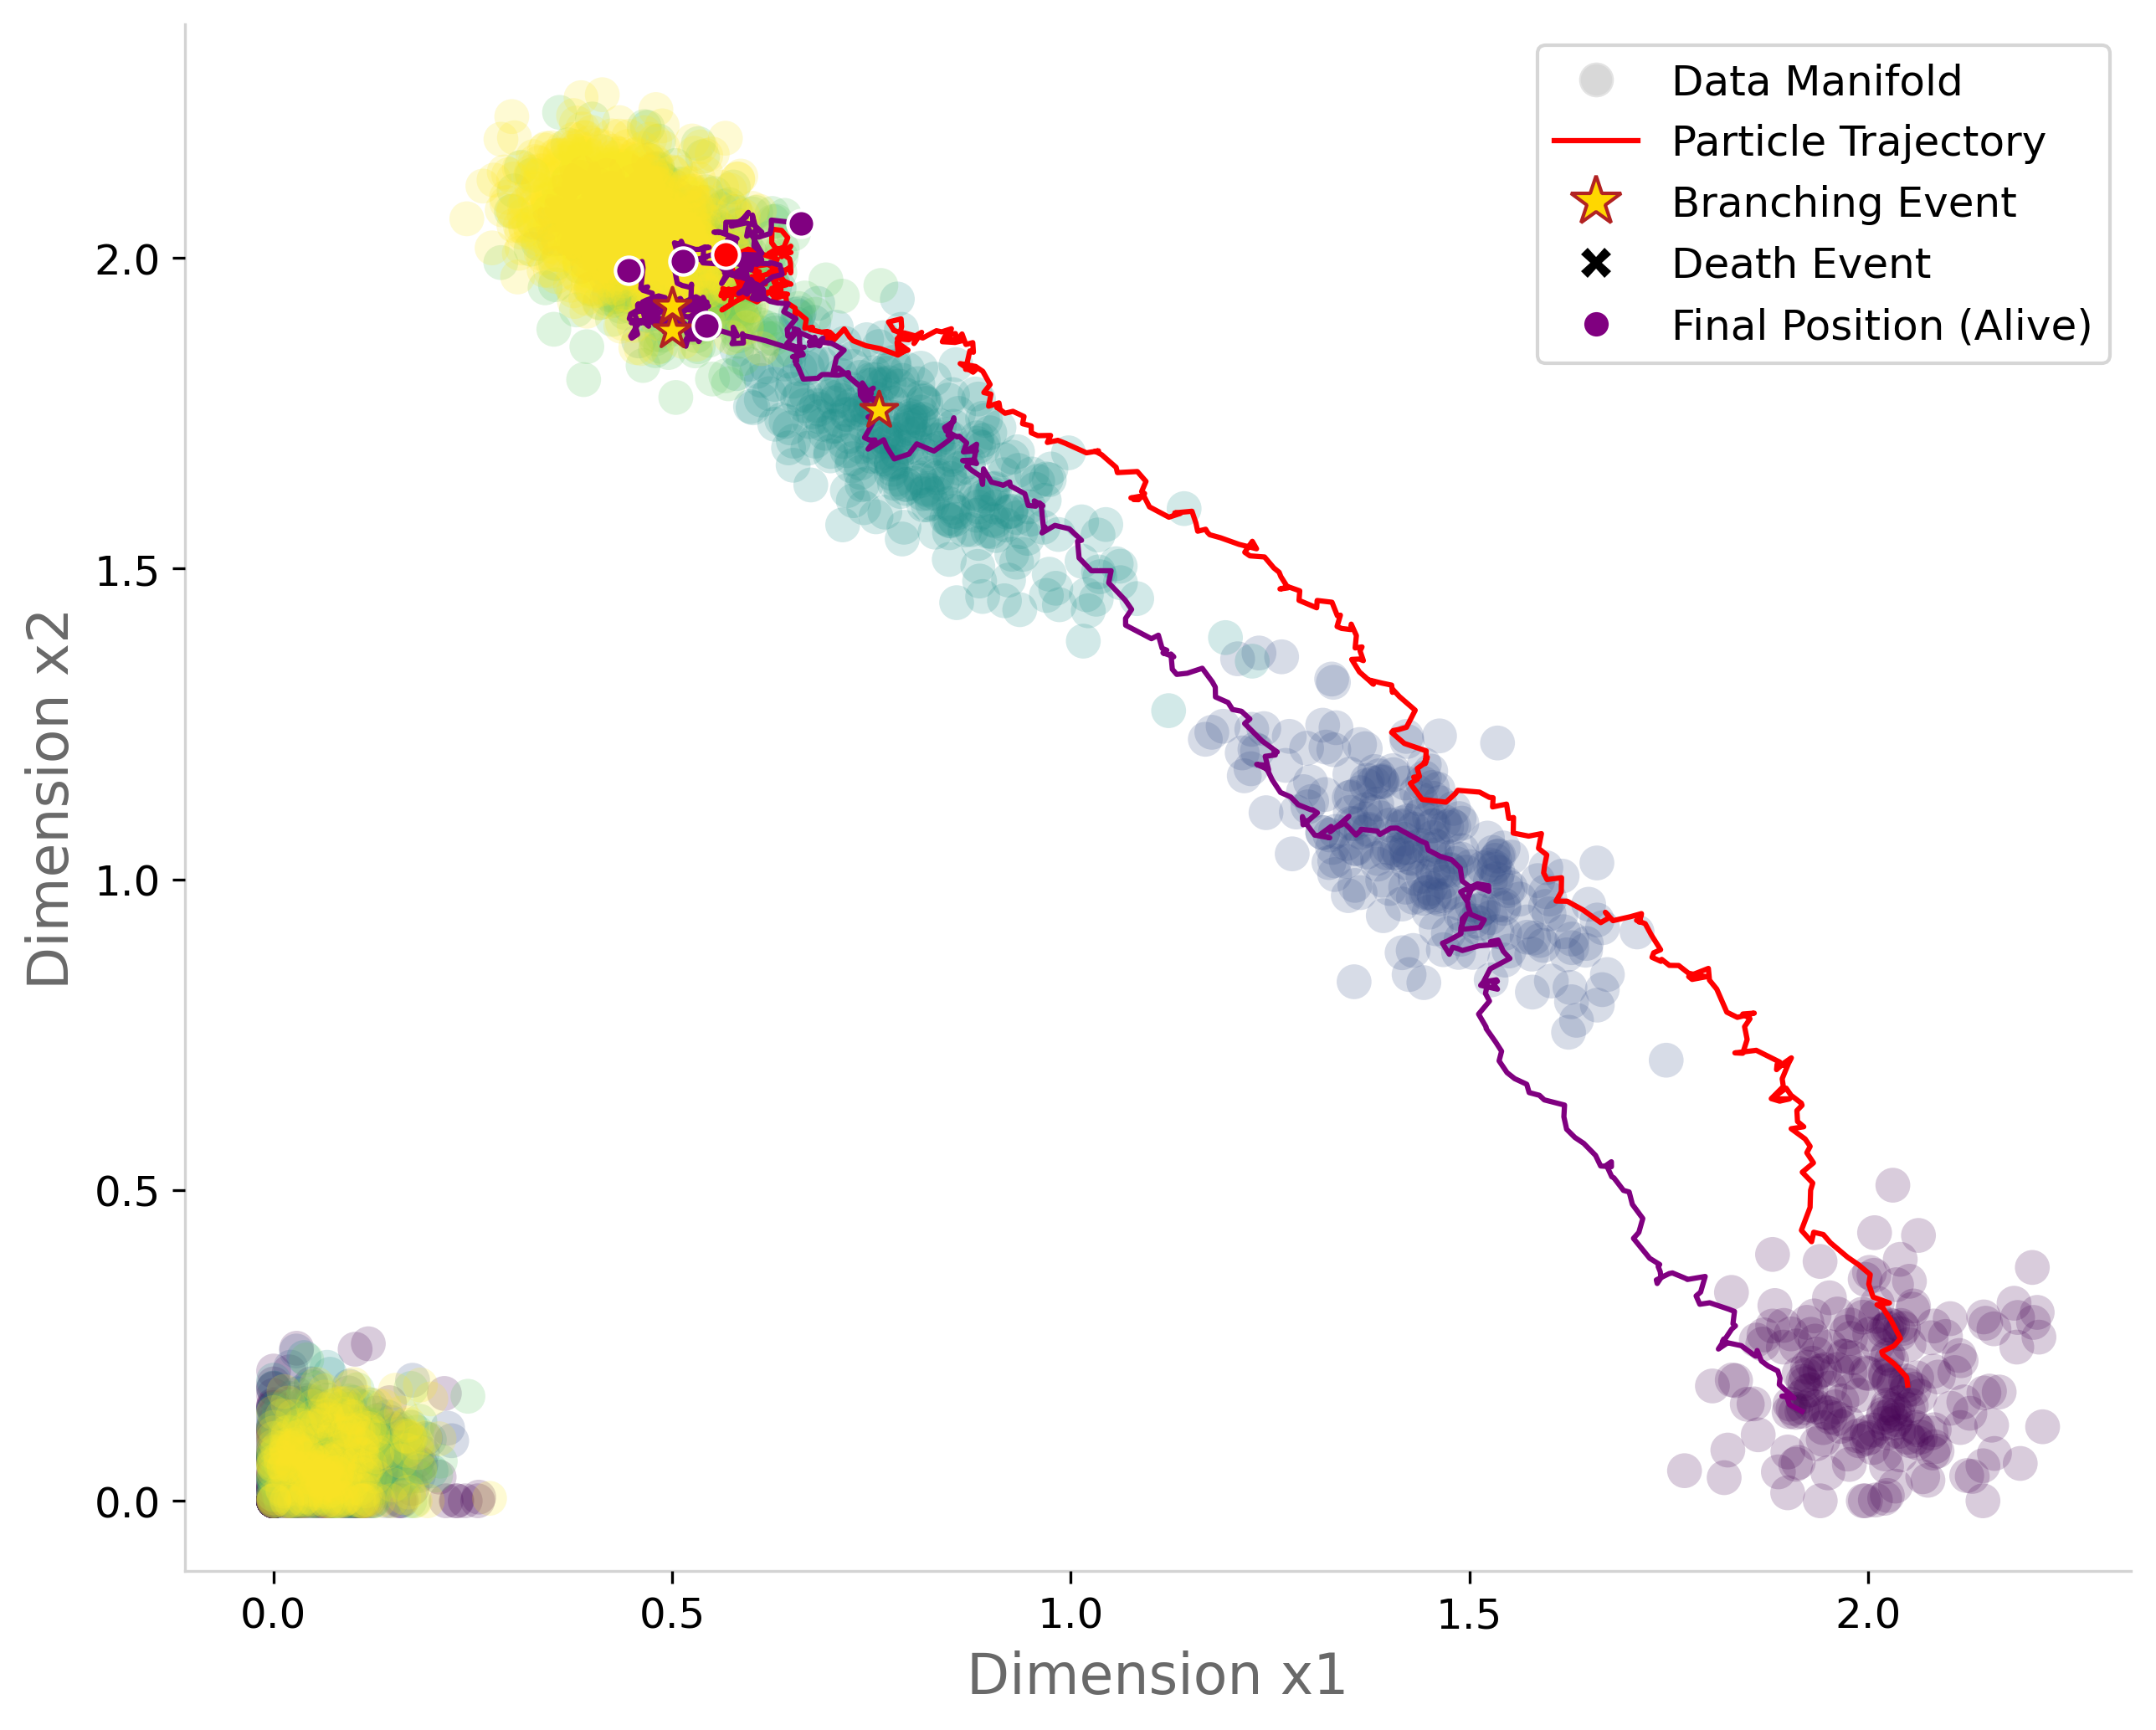

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
ground_truth = True
colors = ['red','purple','black','blue','gray','brown','green','orange']
cells = [0, 100, 300]
for idx in range(len(cells)):
    k = cells[idx]
    x_source = torch.tensor(Xs[0][np.array([k]),:], dtype=torch.float32, device = 'cpu') 
    genealogy, ms, action = simulator.trajectory(
        x=x_source, 
        m=torch.zeros([x_source.size(0),1], device='cpu'), 
        delta=delta, 
        T=max_sample_time, 
        N=max_sample_time*100
    ) 
    plot_branching_phase_portrait2(
        ax,
        df=data, 
        trajectories=genealogy, # 这里传入 mode=3 的字典
        simulation_t=max_sample_time,
        x='x1', y='x2',
        ground_truth=ground_truth,
        color = colors[idx],legend_loc = legend_loc
    )
    ground_truth = False
plt.savefig(f'{data_name}_lineage.png')